<a href="https://colab.research.google.com/github/manojmulammagari/Q-Skill-Internship-Projects/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)
num_samples = 600

# Generate realistic features for residential properties
data = {
    'House_ID': range(1001, 1001 + num_samples),
    'Square_Footage': np.random.normal(2100, 500, num_samples),
    'Total_Rooms': np.random.randint(3, 10, num_samples),
    'Bathrooms': np.random.randint(1, 5, num_samples),
    'Neighborhood_Quality_Index': np.random.uniform(1, 10, num_samples),
    'Distance_To_Center_KM': np.random.uniform(0.5, 25, num_samples),
    'Year_Built': np.random.randint(1950, 2024, num_samples)
}

# Construct target variable 'Price_USD' with weighted linear combination + noise
# Base price + (SqFt * 150) + (Rooms * 5000) - (Dist * 2000) + (Quality * 12000) + noise
noise = np.random.normal(0, 15000, num_samples)
price = (50000 + (data['Square_Footage'] * 165) + (data['Total_Rooms'] * 4500) +
         (data['Neighborhood_Quality_Index'] * 13000) - (data['Distance_To_Center_KM'] * 2200) + noise)

data['Price_USD'] = price

# Create DataFrame and save to CSV for production simulation
housing_df = pd.DataFrame(data)
housing_df.to_csv('housing_market_production_data.csv', index=False)

# Reload the dataset to confirm storage integrity
df = pd.read_csv('housing_market_production_data.csv')
print("Dataset generated and stored successfully.")
display(df.head())

Dataset generated and stored successfully.


,House_ID,Square_Footage,Total_Rooms,Bathrooms,Neighborhood_Quality_Index,Distance_To_Center_KM,Year_Built,Price_USD
0,1001,2348.357077,9,1,2.106737,8.975051,2013,483610.691352
1,1002,2030.867849,6,1,3.080178,8.222143,1978,397936.633616
2,1003,2423.844269,6,4,1.465272,19.410514,1977,467030.876695
3,1004,2861.514928,7,2,6.760027,2.617403,1960,625381.051786
4,1005,1982.923313,4,1,3.022311,6.301216,2014,425564.072966


In [2]:
# 1. Structural Integrity Check
print("--- Dataset Information ---")
display(df.info())

print("\n--- Statistical Summary ---")
display(df.describe().T)

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# 2. Exploratory Trend Analysis
print("\n--- Average Price Trends by Total Rooms ---")
room_pricing = df.groupby('Total_Rooms')['Price_USD'].mean().sort_index()
display(room_pricing)

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   House_ID                    600 non-null    int64  
 1   Square_Footage              600 non-null    float64
 2   Total_Rooms                 600 non-null    int64  
 3   Bathrooms                   600 non-null    int64  
 4   Neighborhood_Quality_Index  600 non-null    float64
 5   Distance_To_Center_KM       600 non-null    float64
 6   Year_Built                  600 non-null    int64  
 7   Price_USD                   600 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 37.6 KB


None


--- Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
House_ID,600.0,1300.500000,173.349358,1001.000000,1150.750000,1300.500000,1450.250000,1600.000000
Square_Footage,600.0,2093.240365,486.095739,479.366330,1752.693213,2103.869190,2411.583702,4026.365745
Total_Rooms,600.0,5.951667,2.035412,3.000000,4.000000,6.000000,8.000000,9.000000
Bathrooms,600.0,2.523333,1.132074,1.000000,2.000000,3.000000,4.000000,4.000000
Neighborhood_Quality_Index,600.0,5.403754,2.567356,1.002993,3.079499,5.479751,7.640936,9.959324
Distance_To_Center_KM,600.0,12.683302,7.135565,0.504616,6.380023,12.742767,18.876726,24.992988
Year_Built,600.0,1987.031667,21.027544,1950.000000,1969.000000,1987.000000,2005.000000,2023.000000
Price_USD,600.0,465303.424211,90921.552027,238061.919049,402242.367440,468160.223994,521337.156862,762303.358701



--- Missing Values Check ---
House_ID                      0
Square_Footage                0
Total_Rooms                   0
Bathrooms                     0
Neighborhood_Quality_Index    0
Distance_To_Center_KM         0
Year_Built                    0
Price_USD                     0
dtype: int64

--- Average Price Trends by Total Rooms ---


,Price_USD
Total_Rooms,
3,450145.642285
4,449892.583189
5,465194.367052
6,470181.259470
7,480248.020860
8,468780.994875
9,475205.240717


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (dropping ID and target) and label
X = df.drop(columns=['House_ID', 'Price_USD'])
y = df['Price_USD']

# Perform 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling: Vital for Linear Models to ensure coefficients are on comparable scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (480, 6)
Testing set shape: (120, 6)


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Generate predictions for evaluation
y_pred = model.predict(X_test_scaled)

# Calculate Performance Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Model Core Performance Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

--- Model Core Performance Metrics ---
Mean Absolute Error (MAE): $13,665.63
Root Mean Squared Error (RMSE): $16,828.13
R-squared Score (R2): 0.9664


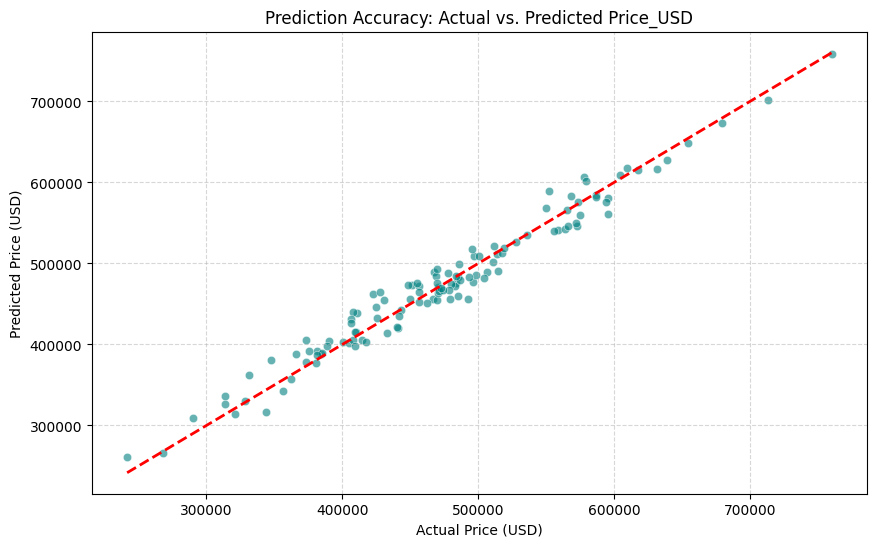

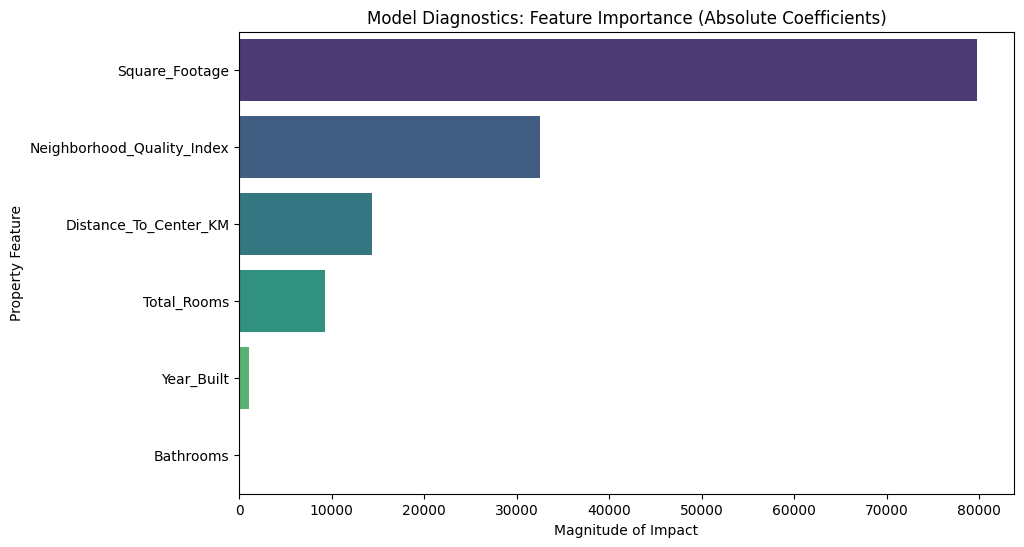

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Actual vs. Predicted Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Prediction Accuracy: Actual vs. Predicted Price_USD')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Plot 2: Feature Importance (Coefficients)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(model.coef_)
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=coefficients, palette='viridis', hue='Feature', legend=False)
plt.title('Model Diagnostics: Feature Importance (Absolute Coefficients)')
plt.xlabel('Magnitude of Impact')
plt.ylabel('Property Feature')
plt.show()

In [13]:
# Define new house features as a DataFrame to maintain feature name consistency
new_house_data = pd.DataFrame([[2500, 8, 3, 8.5, 5, 2015]],
                             columns=['Square_Footage', 'Total_Rooms', 'Bathrooms',
                                      'Neighborhood_Quality_Index', 'Distance_To_Center_KM', 'Year_Built'])

# Scale using the existing scaler
new_house_scaled = scaler.transform(new_house_data)

# Predict price
predicted_price = model.predict(new_house_scaled)

print(f"Predicted Price for the new house: ${predicted_price[0]:,.2f}")

Predicted Price for the new house: $597,718.47
